# Forest Cover Type Classification with Spark MLlib

**Big Data Analytics and Text Mining — Module 2**
Luca Mongiello & Xiaojun Liang — University of Bologna

Supervised multiclass classification of forest cover type (7 classes) on the
UCI **Covertype** dataset (N = 581,012, p = 54), using Spark MLlib on a 2-node
cluster (1 master + 1 worker), with data on **HDFS** and Spark running on **YARN**.

---

## Environment and required library versions

This notebook is meant to run on the cluster provisioned by the project's
`Vagrantfile` + `bootstrap.sh`. To run it as-is, the following versions are required:

| Component   | Version |
|-------------|---------|
| Spark       | 4.1.2   |
| Hadoop      | 3.5.0   |
| Java        | 17      |
| Python      | 3.12.3  |
| pyspark     | 4.1.2   |
| pandas      | 3.0.3   |
| numpy       | 2.5.0   |
| matplotlib  | 3.11.0  |
| seaborn     | 0.13.2  |

The cell below prints the versions actually present at runtime, so any mismatch
with the table above is immediately visible.

In [1]:
import sys
import pyspark, pandas, numpy, matplotlib, seaborn

print("Python    ", sys.version.split()[0])
print("pyspark   ", pyspark.__version__)
print("pandas    ", pandas.__version__)
print("numpy     ", numpy.__version__)
print("matplotlib", matplotlib.__version__)
print("seaborn   ", seaborn.__version__)

Python     3.12.3
pyspark    4.1.2
pandas     3.0.3
numpy      2.5.0
matplotlib 3.11.0
seaborn    0.13.2


## 1. Configuration

All environment-specific values live here, in a single block. Nothing
downstream hard-codes paths, resources, or seeds: to adapt the notebook to a
different cluster, only this cell needs to change.

In [2]:
class CONFIG:
    # --- Spark on YARN ---
    SPARK_MASTER       = "yarn"
    DEPLOY_MODE        = "client"
    APP_NAME           = "covertype"
    DRIVER_MEMORY      = "1g"        
    EXECUTOR_INSTANCES = 1           
    EXECUTOR_CORES     = 3
    EXECUTOR_MEMORY    = "2500m"
    EXECUTOR_OVERHEAD  = "512m"   
    AM_MEMORY          = "512m"      
    SHUFFLE_PARTITIONS = 12          

    # --- Data on HDFS ---
    HDFS_DIR  = "hdfs:///user/vagrant/covtype"
    HDFS_RAW  = HDFS_DIR + "/covtype.data.gz"
    LOCAL_RAW = "/home/vagrant/covtype.data.gz"   # staging path on the driver
    DATA_URL  = ("https://archive.ics.uci.edu/ml/"
                 "machine-learning-databases/covtype/covtype.data.gz")

    # --- Reproducibility / splits ---
    SEED       = 42
    TRAIN_FRAC = 0.8
    TEST_FRAC  = 0.2

## 2. SparkSession on YARN

The session is built explicitly from `CONFIG` (we launch a plain Jupyter, not the
`pyspark` wrapper, precisely so that we control resources here). After creation
the cell prints the Spark version, the application id, and the YARN tracking URL,
where the running application should appear under
[192.168.56.10:8088](http://192.168.56.10:8088).

In [3]:
from pyspark.sql import SparkSession

spark = (
    SparkSession.builder
    .appName(CONFIG.APP_NAME)
    .master(CONFIG.SPARK_MASTER)
    .config("spark.submit.deployMode",      CONFIG.DEPLOY_MODE)
    .config("spark.executor.instances",     CONFIG.EXECUTOR_INSTANCES)
    .config("spark.executor.cores",         CONFIG.EXECUTOR_CORES)
    .config("spark.executor.memory",        CONFIG.EXECUTOR_MEMORY)
    .config("spark.executor.memoryOverhead",CONFIG.EXECUTOR_OVERHEAD)
    .config("spark.yarn.am.memory",         CONFIG.AM_MEMORY)
    .config("spark.driver.memory",          CONFIG.DRIVER_MEMORY)
    .config("spark.sql.shuffle.partitions", CONFIG.SHUFFLE_PARTITIONS)
    .config("spark.ui.showConsoleProgress", "false")
    .getOrCreate()
)
spark.sparkContext.setLogLevel("WARN")

print("Spark version :", spark.version)
print("Application ID:", spark.sparkContext.applicationId)
print("Master        :", spark.sparkContext.master)
print("Tracking UI   : http://192.168.56.10:8088")

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/06/25 09:49:58 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
26/06/25 09:50:00 WARN Client: Neither spark.yarn.jars nor spark.yarn.archive is set, falling back to uploading libraries under SPARK_HOME.


Spark version : 4.1.2
Application ID: application_1782378317758_0001
Master        : yarn
Tracking UI   : http://192.168.56.10:8088


In [ ]:
# --- Imports ---
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pyspark.sql import functions as F
from pyspark.ml import Pipeline
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml.stat import Correlation
from pyspark.ml.classification import (
    DecisionTreeClassifier, RandomForestClassifier,
    GBTClassifier, MultilayerPerceptronClassifier, OneVsRest,
)
from pyspark.ml.tuning import CrossValidator, ParamGridBuilder
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

## 3. Data acquisition on HDFS

The dataset is downloaded once to the driver, then copied to HDFS under
`/user/vagrant/covtype/`. The step is **idempotent**: if the file already exists
on HDFS it is not re-downloaded or re-uploaded, so re-running the notebook is safe.

Note: `covtype.data.gz` is gzip-compressed and therefore not splittable, so Spark
will read it with a single task — fine for a ~11 MB file. We will repartition right
after loading (next section) so the 581k rows are distributed across the executors.

In [5]:
import os, subprocess, urllib.request

os.environ["HADOOP_ROOT_LOGGER"] = "ERROR,console"

def hdfs_exists(path: str) -> bool:
    return subprocess.run(["hdfs", "dfs", "-test", "-e", path]).returncode == 0

def sh(cmd: list):
    print("+", " ".join(cmd))
    subprocess.run(cmd, check=True)

# 1. Ensure the HDFS target directory exists
sh(["hdfs", "dfs", "-mkdir", "-p", CONFIG.HDFS_DIR])

# 2. Download + put only if the file is not already on HDFS
if hdfs_exists(CONFIG.HDFS_RAW):
    print("Already on HDFS:", CONFIG.HDFS_RAW)
else:
    if not os.path.exists(CONFIG.LOCAL_RAW):
        print("Downloading:", CONFIG.DATA_URL)
        urllib.request.urlretrieve(CONFIG.DATA_URL, CONFIG.LOCAL_RAW)
        print("Saved to:", CONFIG.LOCAL_RAW)
    sh(["hdfs", "dfs", "-put", "-f", CONFIG.LOCAL_RAW, CONFIG.HDFS_RAW])
    print("Uploaded to HDFS:", CONFIG.HDFS_RAW)

# 3. Confirm
sh(["hdfs", "dfs", "-ls", CONFIG.HDFS_DIR])

+ hdfs dfs -mkdir -p hdfs:///user/vagrant/covtype
Already on HDFS: hdfs:///user/vagrant/covtype/covtype.data.gz
+ hdfs dfs -ls hdfs:///user/vagrant/covtype
Found 1 items
-rw-r--r--   1 vagrant supergroup   11240707 2026-06-24 11:36 hdfs:///user/vagrant/covtype/covtype.data.gz


## 4. Schema definition and data loading

The schema is declared **explicitly** (no inference): every one of the 55 columns
of `covtype.data` is an integer — 10 quantitative features, 4 wilderness-area
indicators, 40 soil-type indicators, and the `Cover_Type` label (values 1..7).

After loading from HDFS we `repartition` (the gzip file is read by a single task,
so the raw DataFrame has only one partition) and `cache` the result, because the
exploratory analysis will reuse it many times. The final `count()` is the first
real Spark *action* and triggers the actual distributed read on the cluster.

Note: `Cover_Type` ranges 1..7 here; MLlib expects labels starting at 0, so we will
remap it during preprocessing — not now, to keep the load faithful to the raw data.

In [6]:
from pyspark.sql.types import StructType, StructField, IntegerType

# --- Column groups (explicit, reused downstream) ---
QUANTITATIVE = [
    "Elevation",
    "Aspect",
    "Slope",
    "Horizontal_Distance_To_Hydrology",
    "Vertical_Distance_To_Hydrology",
    "Horizontal_Distance_To_Roadways",
    "Hillshade_9am",
    "Hillshade_Noon",
    "Hillshade_3pm",
    "Horizontal_Distance_To_Fire_Points",
]                                                          # 10 quantitative
WILDERNESS = [f"Wilderness_Area_{i}" for i in range(4)]    # 4 binary
SOIL       = [f"Soil_Type_{i}"      for i in range(40)]    # 40 binary
LABEL      = "Cover_Type"                                  # target (1..7)

FEATURE_COLS = QUANTITATIVE + WILDERNESS + SOIL           # 54 features
ALL_COLS     = FEATURE_COLS + [LABEL]                     # 55 columns

# Every column is an integer -> a single explicit schema, no inference.
# (nullable=False states intent only; the CSV reader forces nullable=true,
#  so printSchema below will still show every column as nullable.)
schema = StructType([
    StructField(name, IntegerType(), nullable=False) for name in ALL_COLS
])

print(f"Schema defined: {len(schema.fields)} columns "
      f"({len(QUANTITATIVE)} quantitative + {len(WILDERNESS)} wilderness "
      f"+ {len(SOIL)} soil + 1 label).")

Schema defined: 55 columns (10 quantitative + 4 wilderness + 40 soil + 1 label).


In [7]:
# --- Load the raw .gz from HDFS using the explicit schema ---
df_raw = (
    spark.read
    .schema(schema)             # no inferSchema: types are fixed above
    .option("header", "false")  # covtype.data has no header row
    .csv(CONFIG.HDFS_RAW)
)

# gzip is not splittable -> df_raw has 1 partition. Repartition to spread the
# 581k rows across executors, then cache (the EDA reuses this DataFrame a lot).
df = df_raw.repartition(CONFIG.SHUFFLE_PARTITIONS).cache()

# First real ACTION: triggers read + repartition + cache on the cluster.
n_rows = df.count()

print(f"Rows loaded : {n_rows:,}")
print(f"Partitions  : {df.rdd.getNumPartitions()}")
print(f"Columns     : {len(df.columns)}")
print(f"Matches expected 581,012 rows: {n_rows == 581012}")

26/06/25 09:50:14 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


Rows loaded : 581,012
Partitions  : 12
Columns     : 55
Matches expected 581,012 rows: True


In [8]:
df.printSchema()
df.select(QUANTITATIVE + [LABEL]).limit(5).toPandas()

root
 |-- Elevation: integer (nullable = true)
 |-- Aspect: integer (nullable = true)
 |-- Slope: integer (nullable = true)
 |-- Horizontal_Distance_To_Hydrology: integer (nullable = true)
 |-- Vertical_Distance_To_Hydrology: integer (nullable = true)
 |-- Horizontal_Distance_To_Roadways: integer (nullable = true)
 |-- Hillshade_9am: integer (nullable = true)
 |-- Hillshade_Noon: integer (nullable = true)
 |-- Hillshade_3pm: integer (nullable = true)
 |-- Horizontal_Distance_To_Fire_Points: integer (nullable = true)
 |-- Wilderness_Area_0: integer (nullable = true)
 |-- Wilderness_Area_1: integer (nullable = true)
 |-- Wilderness_Area_2: integer (nullable = true)
 |-- Wilderness_Area_3: integer (nullable = true)
 |-- Soil_Type_0: integer (nullable = true)
 |-- Soil_Type_1: integer (nullable = true)
 |-- Soil_Type_2: integer (nullable = true)
 |-- Soil_Type_3: integer (nullable = true)
 |-- Soil_Type_4: integer (nullable = true)
 |-- Soil_Type_5: integer (nullable = true)
 |-- Soil_Type

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,Cover_Type
0,2773,44,14,90,21,1409,222,208,117,2219,2
1,3235,179,10,450,130,450,225,246,154,631,1
2,2894,89,11,124,21,3303,236,223,117,4696,2
3,3005,352,13,153,25,4290,196,217,158,854,2
4,3285,326,15,524,147,3818,182,222,179,2106,1


## 5. Exploratory Data Analysis

EDA is performed **on the cluster**: aggregations run distributed in Spark, and only
the small aggregated results are pulled to the driver for plotting (never the 581k raw
rows). The course guidelines ask for descriptive statistics both globally and per class
for supervised classification.

Key references for this dataset:
- Blackard & Dean (1999): original dataset; elevation is among the most discriminative features.
- Tavakol Sadrabadi & Innocente (2023): use random undersampling to handle class imbalance.
  They report an imbalance ratio of 77:1 and strong Hillshade collinearity (r≈0.98); on the
  full raw dataset we measured different values (see 5.1 and 5.4), which we discuss critically.

### 5.1 Class distribution and imbalance ratio

The target `Cover_Type` (1..7) is strongly imbalanced. We quantify the imbalance ratio
as Nmax/Nmin over the full dataset. Note: Tavakol Sadrabadi & Innocente (2023) report 77:1,
but that uses class 1 as numerator; the true maximum is class 2, giving ~103:1. Either way
the imbalance is severe, motivating per-class metrics + confusion matrix (not accuracy alone)
and training-set-only undersampling.

 Cover_Type  count       pct
          1 211840 36.460521
          2 283301 48.759922
          3  35754  6.153746
          4   2747  0.472796
          5   9493  1.633873
          6  17367  2.989095
          7  20510  3.530048

Imbalance ratio (max/min): 103.1 : 1


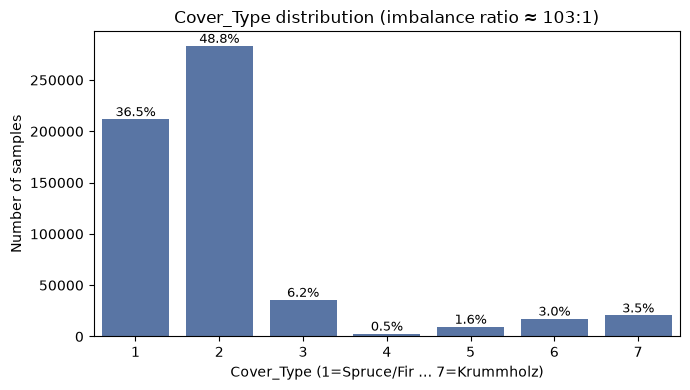

In [9]:
# Aggregate on the cluster: one small row per class.
class_counts = (
    df.groupBy(LABEL).count()
      .orderBy(LABEL)
      .toPandas()
)
class_counts["pct"] = 100 * class_counts["count"] / class_counts["count"].sum()

imbalance_ratio = class_counts["count"].max() / class_counts["count"].min()
print(class_counts.to_string(index=False))
print(f"\nImbalance ratio (max/min): {imbalance_ratio:.1f} : 1")

# Inline bar chart
fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(data=class_counts, x=LABEL, y="count", ax=ax, color="#4C72B0")
ax.set_title(f"Cover_Type distribution (imbalance ratio ≈ {imbalance_ratio:.0f}:1)")
ax.set_xlabel("Cover_Type (1=Spruce/Fir … 7=Krummholz)")
ax.set_ylabel("Number of samples")
for i, row in class_counts.iterrows():
    ax.text(i, row["count"], f"{row['pct']:.1f}%", ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.show()

### 5.2 Global descriptive statistics (quantitative features)

Min, max, mean and standard deviation for the 10 quantitative features, computed
distributed in Spark. The binary wilderness/soil columns are excluded here (their
"statistics" would just be presence frequencies, covered separately).

In [10]:
# describe() is distributed; transpose for readability.
global_stats = (
    df.select(QUANTITATIVE)
      .describe()                       # count, mean, stddev, min, max
      .toPandas()
      .set_index("summary")
      .T
)
# Cast numeric for a clean view
global_stats = global_stats.astype(float).round(2)
global_stats

summary,count,mean,stddev,min,max
Elevation,581012.0,2959.37,279.98,1859.0,3858.0
Aspect,581012.0,155.66,111.91,0.0,360.0
Slope,581012.0,14.10,7.49,0.0,66.0
Horizontal_Distance_To_Hydrology,581012.0,269.43,212.55,0.0,1397.0
Vertical_Distance_To_Hydrology,581012.0,46.42,58.30,-173.0,601.0
Horizontal_Distance_To_Roadways,581012.0,2350.15,1559.25,0.0,7117.0
Hillshade_9am,581012.0,212.15,26.77,0.0,254.0
Hillshade_Noon,581012.0,223.32,19.77,0.0,254.0
Hillshade_3pm,581012.0,142.53,38.27,0.0,254.0
Horizontal_Distance_To_Fire_Points,581012.0,1980.29,1324.20,0.0,7173.0


### 5.3 Per-class statistics

We focus on `Elevation`, the most
discriminative feature according to Blackard & Dean (1999) and the feature-importance
analysis of Tavakol Sadrabadi & Innocente (2023): mean elevation separates several classes.

In [11]:
# Mean of each quantitative feature, grouped by class (distributed).
per_class_mean = (
    df.groupBy(LABEL)
      .agg(*[F.round(F.mean(c), 1).alias(c) for c in QUANTITATIVE])
      .orderBy(LABEL)
      .toPandas()
)
per_class_mean

,Cover_Type,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points
0,1,3128.6,156.1,13.1,270.6,42.2,2614.8,212.0,223.4,143.9,2009.3
1,2,2920.9,152.1,13.6,279.9,45.9,2429.5,213.8,225.3,143.0,2168.2
2,3,2394.5,176.4,20.8,210.3,62.4,943.9,201.9,215.8,140.4,911.0
3,4,2223.9,137.1,18.5,106.9,41.2,914.2,228.3,217.0,111.4,859.1
4,5,2787.4,139.3,16.6,212.4,50.6,1349.8,223.5,219.0,121.9,1577.7
5,6,2419.2,180.5,19.0,159.9,45.4,1037.2,192.8,209.8,148.3,1055.4
6,7,3361.9,153.2,14.3,357.0,69.5,2738.3,217.0,221.7,134.9,2070.0


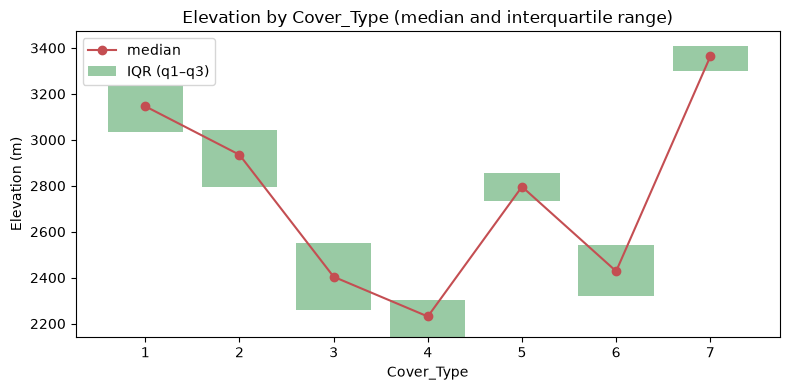

In [12]:
# Elevation distribution per class: aggregate quantiles on the cluster, plot the summary.
elev_by_class = (
    df.groupBy(LABEL)
      .agg(
          F.expr("percentile_approx(Elevation, 0.25)").alias("q1"),
          F.expr("percentile_approx(Elevation, 0.5)").alias("median"),
          F.expr("percentile_approx(Elevation, 0.75)").alias("q3"),
      )
      .orderBy(LABEL)
      .toPandas()
)

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(elev_by_class[LABEL], elev_by_class["q3"] - elev_by_class["q1"],
       bottom=elev_by_class["q1"], color="#55A868", alpha=0.6, label="IQR (q1–q3)")
ax.plot(elev_by_class[LABEL], elev_by_class["median"], "o-", color="#C44E52", label="median")
ax.set_title("Elevation by Cover_Type (median and interquartile range)")
ax.set_xlabel("Cover_Type")
ax.set_ylabel("Elevation (m)")
ax.legend()
plt.tight_layout()
plt.show()

### 5.4 Correlation of quantitative features

Pearson correlation among the 10 quantitative features, computed on the cluster.
We specifically check the Hillshade_9am / Hillshade_3pm pair: the literature reports
r≈+0.98, but on the full raw dataset we measure **r=−0.78** — a strong but *negative*
correlation (complementary, not redundant information). Combined with the fact that 3 of
our 4 models are tree-based (insensitive to collinearity by construction), this is why we
keep all 54 features rather than dropping a hillshade column.

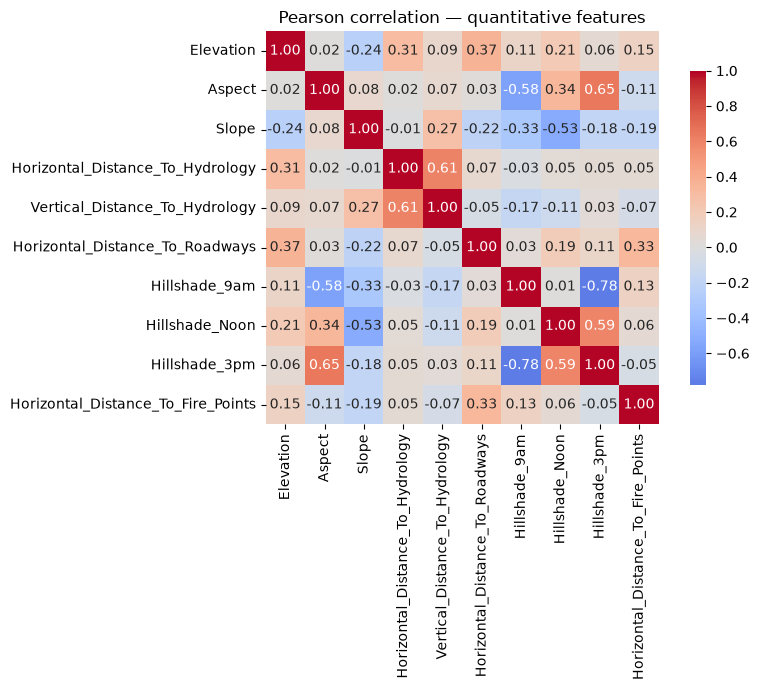

In [13]:
# Assemble quantitative features into a vector, compute the correlation matrix on the cluster.
assembler = VectorAssembler(inputCols=QUANTITATIVE, outputCol="_quant_vec")
vec_df = assembler.transform(df.select(QUANTITATIVE))
corr_matrix = Correlation.corr(vec_df, "_quant_vec", "pearson").head()[0].toArray()

corr_pd = pd.DataFrame(corr_matrix, index=QUANTITATIVE, columns=QUANTITATIVE)

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr_pd, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            square=True, cbar_kws={"shrink": 0.8}, ax=ax)
ax.set_title("Pearson correlation — quantitative features")
plt.tight_layout()
plt.show()

## 6. Preprocessing

Three steps, each justified by earlier findings:

1. **Label remapping** `Cover_Type` 1..7 → 0..6. Spark MLlib expects zero-based labels;
   the raw data is 1-based (kept faithful at load time, remapped here).
2. **Stratified train/test split** (80/20, fixed `SEED`). Stratification preserves the
   severe class imbalance (~103:1) in both splits, so the test set reflects the real
   distribution and per-class metrics are meaningful. Note: because the load uses a
   round-robin `repartition` and `sampleBy` draws per-partition Bernoulli samples, the
   `SEED` makes the split *statistically* reproducible (proportions and metrics stable to
   roughly ±0.5% across fresh runs), not bit-for-bit identical row-by-row.
3. **Training-set-only undersampling**, following Tavakol Sadrabadi & Innocente (2023).
   We balance ONLY the training set; the test set keeps the original distribution, so we
   never evaluate on artificially balanced data.

All 54 features are assembled into a single vector (`VectorAssembler`), as required by MLlib.
Scaling (`StandardScaler`) is applied only for the MLP later, not here — trees don't need it.

In [14]:
# 1. Remap Cover_Type 1..7 -> 0..6 (MLlib expects zero-based labels)
LABEL_IDX = "label"  # conventional name for the remapped target
df_ml = df.withColumn(LABEL_IDX, F.col(LABEL) - 1)

# 2. Assemble the 54 features into a single vector column.
#    A stable "_id" is attached for a robust anti-join split (see next cell);
#    it is NOT a feature — the models only read "features" and the label column.
assembler_feat = VectorAssembler(inputCols=FEATURE_COLS, outputCol="features")
df_ml = (
    assembler_feat.transform(df_ml)
    .select("features", LABEL_IDX)
    .withColumn("_id", F.monotonically_increasing_id())
    .cache()
)

# Sanity check: label range and row count preserved
label_range = df_ml.agg(F.min(LABEL_IDX), F.max(LABEL_IDX)).first()
print(f"Label range after remap: {label_range[0]}..{label_range[1]}  (expected 0..6)")
print(f"Rows: {df_ml.count():,}  Features per row: {len(FEATURE_COLS)}")

# EDA is done and df_ml is now built + cached -> free the raw df's cache.
df.unpersist()

Label range after remap: 0..6  (expected 0..6)
Rows: 581,012  Features per row: 54


DataFrame[Elevation: int, Aspect: int, Slope: int, Horizontal_Distance_To_Hydrology: int, Vertical_Distance_To_Hydrology: int, Horizontal_Distance_To_Roadways: int, Hillshade_9am: int, Hillshade_Noon: int, Hillshade_3pm: int, Horizontal_Distance_To_Fire_Points: int, Wilderness_Area_0: int, Wilderness_Area_1: int, Wilderness_Area_2: int, Wilderness_Area_3: int, Soil_Type_0: int, Soil_Type_1: int, Soil_Type_2: int, Soil_Type_3: int, Soil_Type_4: int, Soil_Type_5: int, Soil_Type_6: int, Soil_Type_7: int, Soil_Type_8: int, Soil_Type_9: int, Soil_Type_10: int, Soil_Type_11: int, Soil_Type_12: int, Soil_Type_13: int, Soil_Type_14: int, Soil_Type_15: int, Soil_Type_16: int, Soil_Type_17: int, Soil_Type_18: int, Soil_Type_19: int, Soil_Type_20: int, Soil_Type_21: int, Soil_Type_22: int, Soil_Type_23: int, Soil_Type_24: int, Soil_Type_25: int, Soil_Type_26: int, Soil_Type_27: int, Soil_Type_28: int, Soil_Type_29: int, Soil_Type_30: int, Soil_Type_31: int, Soil_Type_32: int, Soil_Type_33: int, S

In [15]:
# Stratified 80/20 split: sample each class separately to preserve the imbalance.
fractions = {c: CONFIG.TRAIN_FRAC for c in range(7)}  # labels 0..6
train_df = df_ml.sampleBy(LABEL_IDX, fractions=fractions, seed=CONFIG.SEED).cache()
# Test = complement via a stable-id anti-join (correct under duplicate rows,
# and cheaper than subtract/EXCEPT which would also dedup identical rows).
test_df  = df_ml.join(train_df.select("_id"), on="_id", how="left_anti").cache()

print(f"Train rows: {train_df.count():,}")
print(f"Test  rows: {test_df.count():,}")

# Verify both splits keep the original (imbalanced) class proportions
print("\nClass proportions (train vs test):")
train_dist = train_df.groupBy(LABEL_IDX).count().orderBy(LABEL_IDX).toPandas()
test_dist  = test_df.groupBy(LABEL_IDX).count().orderBy(LABEL_IDX).toPandas()
train_dist["train_pct"] = 100 * train_dist["count"] / train_dist["count"].sum()
test_dist["test_pct"]   = 100 * test_dist["count"]  / test_dist["count"].sum()
comparison = train_dist[[LABEL_IDX, "train_pct"]].merge(
    test_dist[[LABEL_IDX, "test_pct"]], on=LABEL_IDX)
print(comparison.round(2).to_string(index=False))

Train rows: 465,178
Test  rows: 115,834

Class proportions (train vs test):
 label  train_pct  test_pct
     0      36.50     36.31
     1      48.74     48.85
     2       6.15      6.18
     3       0.47      0.48
     4       1.64      1.63
     5       2.99      2.98
     6       3.52      3.57


In [16]:
# Undersample the TRAINING set only, to the size of its smallest class.
# Test set is left untouched (keeps the real distribution).
train_class_counts = (
    train_df.groupBy(LABEL_IDX).count().orderBy(LABEL_IDX).toPandas()
)
min_count = int(train_class_counts["count"].min())
print(f"Smallest training class: {min_count:,} rows -> target per class after undersampling")

# Fraction to sample from each class so every class ends with ~min_count rows
undersample_fractions = {
    int(row[LABEL_IDX]): min(1.0, min_count / row["count"])
    for _, row in train_class_counts.iterrows()
}
train_bal = train_df.sampleBy(LABEL_IDX, fractions=undersample_fractions, seed=CONFIG.SEED).cache()

print(f"\nBalanced training rows: {train_bal.count():,}")
print("Balanced training distribution:")
print(train_bal.groupBy(LABEL_IDX).count().orderBy(LABEL_IDX).toPandas().to_string(index=False))

# train_df, test_df and train_bal are now cached -> df_ml is no longer needed.
df_ml.unpersist()

Smallest training class: 2,192 rows -> target per class after undersampling

Balanced training rows: 15,360
Balanced training distribution:
 label  count
     0   2163
     1   2229
     2   2188
     3   2192
     4   2188
     5   2158
     6   2242


DataFrame[features: vector, label: int, _id: bigint]

In [17]:
print("Feature vector size:", train_bal.select("features").first()[0].size)  # must be 54
print("Columns in train_bal:", train_bal.columns)  # _id present is fine, features/label must exist

Feature vector size: 54
Columns in train_bal: ['features', 'label', '_id']


## 7. Models

Four classifiers are trained on the **balanced** training set and evaluated on the
**untouched** test set (real ~103:1 distribution), so metrics reflect real-world performance:

- **Decision Tree**, **Random Forest** — directly multiclass, use the raw `features` vector.
- **GBT** wrapped in **OneVsRest** — Spark's `GBTClassifier` is binary-only, so OneVsRest
  trains one GBT per class (7 models).
- **MLP** (`MultilayerPerceptronClassifier`) — needs scaled inputs, so it runs inside a
  Pipeline with `StandardScaler`; layers = [54, 32, 7] (54 features in, 7 classes out).
  Motivated by Blackard & Dean (1999), who used a feed-forward network on scaled features.

This section establishes **baselines** (default-ish hyperparameters). Tuning with
`CrossValidator` + `ParamGridBuilder` is added on top in the next section.

Evaluation uses per-class precision/recall/F1 and a confusion matrix — not accuracy alone,
given the severe imbalance.

In [18]:
RESULTS = {}  # collects metrics for the final comparison table

_eval_acc = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="accuracy")
_eval_f1  = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="f1")
CLASSES = [f"C{i+1}" for i in range(7)]   # display labels 1..7

def evaluate(name, model, test, train_time):
    """Per-class precision/recall/F1 + confusion matrix on the (imbalanced) test set."""
    preds = model.transform(test).select("label", "prediction")
    acc = _eval_acc.evaluate(preds)
    f1w = _eval_f1.evaluate(preds)

    # Confusion matrix built from a distributed groupBy (no raw rows pulled to driver)
    cm_long = preds.groupBy("label", "prediction").count().toPandas()
    cm = (cm_long.pivot(index="label", columns="prediction", values="count")
                 .reindex(index=range(7), columns=range(7)).fillna(0).astype(int))
    cm_v = cm.values.astype(float)

    tp = np.diag(cm_v)
    fp = cm_v.sum(axis=0) - tp
    fn = cm_v.sum(axis=1) - tp
    prec = np.divide(tp, tp + fp, out=np.zeros(7), where=(tp + fp) > 0)
    rec  = np.divide(tp, tp + fn, out=np.zeros(7), where=(tp + fn) > 0)
    f1c  = np.divide(2 * prec * rec, prec + rec, out=np.zeros(7), where=(prec + rec) > 0)
    per_class = pd.DataFrame(
        {"precision": prec.round(3), "recall": rec.round(3), "f1": f1c.round(3)},
        index=CLASSES,
    )

    RESULTS[name] = {"accuracy": acc, "weighted_f1": f1w,
                     "train_time_s": train_time, "per_class": per_class, "cm": cm}

    print(f"{name}:  accuracy={acc:.4f}   weighted_F1={f1w:.4f}   train_time={train_time:.1f}s\n")
    print(per_class.to_string())

    # Row-normalized confusion matrix (each row = true class -> recall view)
    cm_norm = cm_v / cm_v.sum(axis=1, keepdims=True).clip(min=1)
    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues",
                xticklabels=CLASSES, yticklabels=CLASSES, ax=ax, cbar_kws={"shrink": 0.8})
    ax.set_title(f"{name} — normalized confusion matrix (row = true class)")
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")
    plt.tight_layout(); plt.show()
    return RESULTS[name]

def run_model(name, estimator, train, test):
    t0 = time.time()
    model = estimator.fit(train)
    return evaluate(name, model, test, time.time() - t0)

Decision Tree:  accuracy=0.6647   weighted_F1=0.6776   train_time=2.8s

    precision  recall     f1
C1      0.687   0.662  0.674
C2      0.781   0.616  0.689
C3      0.755   0.753  0.754
C4      0.550   0.928  0.691
C5      0.192   0.931  0.318
C6      0.490   0.800  0.608
C7      0.498   0.941  0.651


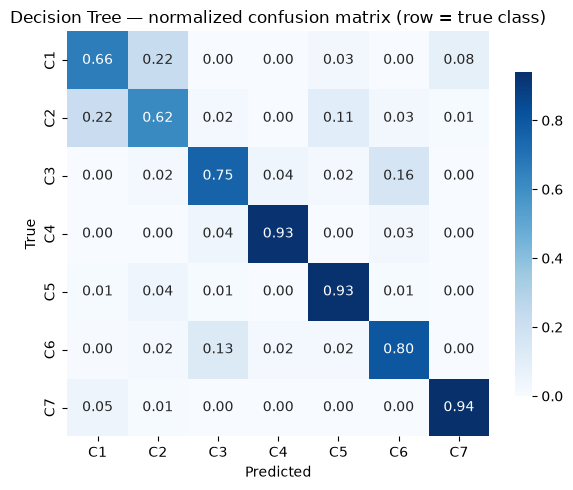

In [19]:
dt = DecisionTreeClassifier(labelCol="label", featuresCol="features",
                            maxDepth=15, seed=CONFIG.SEED)
_ = run_model("Decision Tree", dt, train_bal, test_df)

26/06/25 09:50:32 WARN DAGScheduler: Broadcasting large task binary with size 1089.4 KiB
26/06/25 09:50:32 WARN DAGScheduler: Broadcasting large task binary with size 1682.4 KiB
26/06/25 09:50:33 WARN DAGScheduler: Broadcasting large task binary with size 2.5 MiB
26/06/25 09:50:33 WARN DAGScheduler: Broadcasting large task binary with size 3.5 MiB
26/06/25 09:50:34 WARN DAGScheduler: Broadcasting large task binary with size 4.9 MiB
26/06/25 09:50:34 WARN DAGScheduler: Broadcasting large task binary with size 6.5 MiB
26/06/25 09:50:35 WARN DAGScheduler: Broadcasting large task binary with size 8.4 MiB
26/06/25 09:50:36 WARN DAGScheduler: Broadcasting large task binary with size 10.4 MiB
26/06/25 09:50:37 WARN DAGScheduler: Broadcasting large task binary with size 12.5 MiB
26/06/25 09:50:39 WARN DAGScheduler: Broadcasting large task binary with size 8.0 MiB
26/06/25 09:50:40 WARN DAGScheduler: Broadcasting large task binary with size 8.0 MiB
26/06/25 09:50:42 WARN DAGScheduler: Broadcast

Random Forest:  accuracy=0.6875   weighted_F1=0.7065   train_time=7.8s

    precision  recall     f1
C1      0.732   0.720  0.726
C2      0.839   0.615  0.710
C3      0.781   0.746  0.763
C4      0.436   0.968  0.601
C5      0.166   0.956  0.283
C6      0.476   0.845  0.609
C7      0.497   0.953  0.654


26/06/25 09:50:44 WARN DAGScheduler: Broadcasting large task binary with size 8.0 MiB


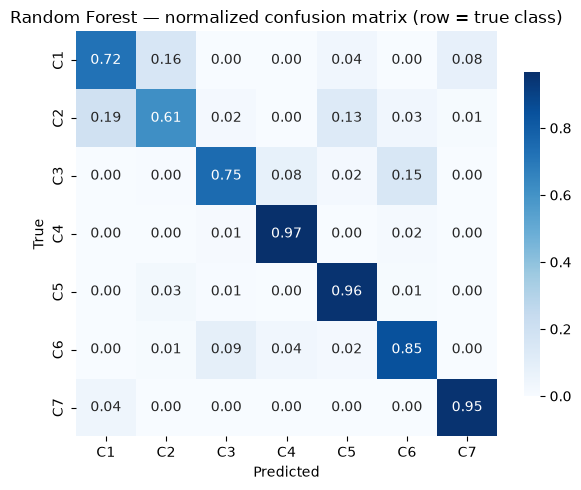

In [20]:
rf = RandomForestClassifier(labelCol="label", featuresCol="features",
                            numTrees=50, maxDepth=15, seed=CONFIG.SEED)
_ = run_model("Random Forest", rf, train_bal, test_df)

26/06/25 09:51:30 WARN DAGScheduler: Broadcasting large task binary with size 1191.6 KiB
26/06/25 09:51:31 WARN DAGScheduler: Broadcasting large task binary with size 1191.6 KiB
26/06/25 09:51:32 WARN DAGScheduler: Broadcasting large task binary with size 1200.9 KiB
26/06/25 09:51:32 WARN DAGScheduler: Broadcasting large task binary with size 1087.4 KiB


GBT (OneVsRest):  accuracy=0.6181   weighted_F1=0.6442   train_time=44.9s

    precision  recall     f1
C1      0.686   0.687  0.687
C2      0.819   0.513  0.631
C3      0.736   0.682  0.708
C4      0.400   0.964  0.565
C5      0.118   0.926  0.209
C6      0.406   0.764  0.531
C7      0.432   0.938  0.592


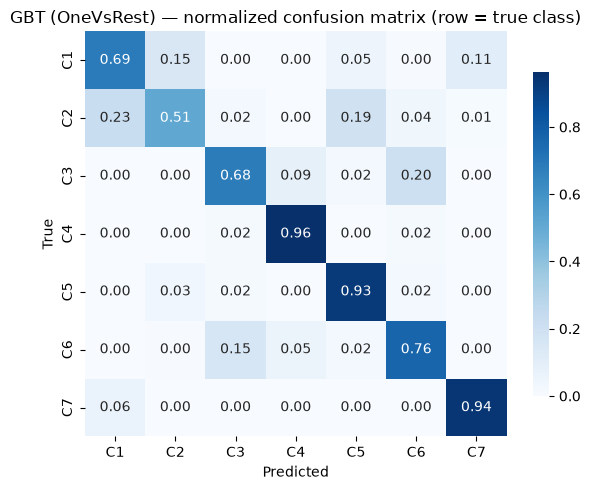

In [21]:
# GBTClassifier is binary-only -> OneVsRest trains one GBT per class (7 models).
gbt = GBTClassifier(labelCol="label", featuresCol="features",
                    maxIter=20, maxDepth=5, seed=CONFIG.SEED)
ovr_gbt = OneVsRest(classifier=gbt, labelCol="label", featuresCol="features")
_ = run_model("GBT (OneVsRest)", ovr_gbt, train_bal, test_df)

26/06/25 09:51:33 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.JNIBLAS


MLP:  accuracy=0.6635   weighted_F1=0.6812   train_time=7.6s

    precision  recall     f1
C1      0.704   0.690  0.697
C2      0.808   0.606  0.693
C3      0.740   0.684  0.710
C4      0.379   0.923  0.537
C5      0.170   0.915  0.287
C6      0.429   0.724  0.539
C7      0.476   0.947  0.633


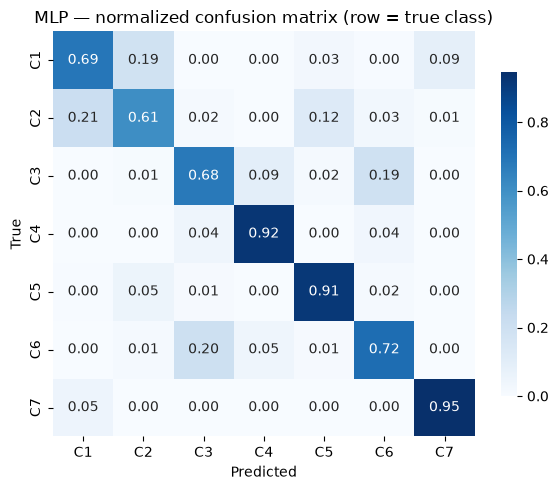

In [22]:
# MLP needs scaled inputs -> StandardScaler inside a Pipeline. layers = [54, 32, 7].
scaler = StandardScaler(inputCol="features", outputCol="scaledFeatures",
                        withMean=True, withStd=True)
mlp = MultilayerPerceptronClassifier(labelCol="label", featuresCol="scaledFeatures",
                                     layers=[len(FEATURE_COLS), 32, 7],
                                     maxIter=100, seed=CONFIG.SEED)
mlp_pipeline = Pipeline(stages=[scaler, mlp])
_ = run_model("MLP", mlp_pipeline, train_bal, test_df)

In [23]:
summary = pd.DataFrame({
    name: {"accuracy": r["accuracy"], "weighted_F1": r["weighted_f1"],
           "train_time_s": round(r["train_time_s"], 1)}
    for name, r in RESULTS.items()
}).T.round(4)
summary

,accuracy,weighted_F1,train_time_s
Decision Tree,0.6647,0.6776,2.8
Random Forest,0.6875,0.7065,7.8
GBT (OneVsRest),0.6181,0.6442,44.9
MLP,0.6635,0.6812,7.6


## 8. Hyperparameter tuning (CrossValidator + ParamGridBuilder)

Each model is tuned with 3-fold cross-validation on the **balanced training set**,
then the best model is evaluated on the **untouched test set** (same `evaluate` function,
so tuned and baseline results land in the same comparison table).

Grids are deliberately small: the 2-node cluster and the GBT/OneVsRest cost (7 models per
fit) make large grids impractical. CV uses weighted-F1 as the selection metric (not accuracy),
consistent with our imbalance-aware evaluation. CV folds are random (not stratified); because
the training set is balanced, each fold is already approximately class-even.

In [24]:
# CV selection metric = weighted F1 (imbalance-aware), reusing the same evaluator
# as the reporting code (_eval_f1) so selection and reporting are provably identical.

CV_FOLDS = 3

def tune_model(name, estimator, param_grid, train, test):
    cv = CrossValidator(
        estimator=estimator,
        estimatorParamMaps=param_grid,
        evaluator=_eval_f1,
        numFolds=CV_FOLDS,
        parallelism=2,          # train up to 2 param combos at once (2-node cluster)
        seed=CONFIG.SEED,
    )
    t0 = time.time()
    cv_model = cv.fit(train)
    elapsed = time.time() - t0
    best = cv_model.bestModel

    n_combos = len(param_grid)
    print(f"[{name}] tuned over {n_combos} param combo(s) x {CV_FOLDS} folds "
          f"in {elapsed:.1f}s")
    # evaluate() stores results in RESULTS under the given name and plots the CM
    evaluate(name, best, test, elapsed)
    return cv_model

[Decision Tree (tuned)] tuned over 3 param combo(s) x 3 folds in 12.9s
Decision Tree (tuned):  accuracy=0.6701   weighted_F1=0.6806   train_time=12.9s

    precision  recall     f1
C1      0.685   0.660  0.672
C2      0.776   0.627  0.693
C3      0.758   0.766  0.762
C4      0.538   0.930  0.681
C5      0.214   0.926  0.347
C6      0.506   0.808  0.622
C7      0.503   0.934  0.654


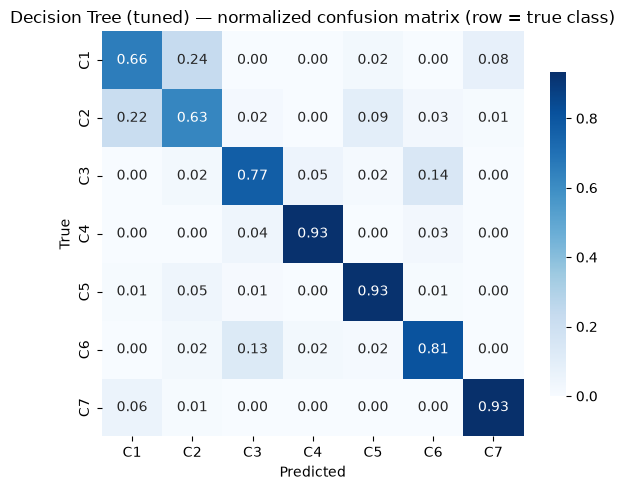

Best maxDepth: 20


In [25]:
dt_base = DecisionTreeClassifier(labelCol="label", featuresCol="features", seed=CONFIG.SEED)
dt_grid = (ParamGridBuilder()
           .addGrid(dt_base.maxDepth, [10, 15, 20])
           .build())
dt_cv = tune_model("Decision Tree (tuned)", dt_base, dt_grid, train_bal, test_df)
print("Best maxDepth:", dt_cv.bestModel.getMaxDepth())

26/06/25 09:51:56 WARN DAGScheduler: Broadcasting large task binary with size 1073.9 KiB
26/06/25 09:51:56 WARN DAGScheduler: Broadcasting large task binary with size 1073.9 KiB
26/06/25 09:51:56 WARN DAGScheduler: Broadcasting large task binary with size 1530.9 KiB
26/06/25 09:51:56 WARN DAGScheduler: Broadcasting large task binary with size 1530.9 KiB
26/06/25 09:51:56 WARN DAGScheduler: Broadcasting large task binary with size 2.1 MiB
26/06/25 09:51:57 WARN DAGScheduler: Broadcasting large task binary with size 2.1 MiB
26/06/25 09:51:57 WARN DAGScheduler: Broadcasting large task binary with size 2.8 MiB
26/06/25 09:51:57 WARN DAGScheduler: Broadcasting large task binary with size 3.6 MiB
26/06/25 09:51:58 WARN DAGScheduler: Broadcasting large task binary with size 4.5 MiB
26/06/25 09:51:58 WARN DAGScheduler: Broadcasting large task binary with size 1611.3 KiB
26/06/25 09:51:58 WARN DAGScheduler: Broadcasting large task binary with size 5.5 MiB
26/06/25 09:51:59 WARN DAGScheduler: Br

[Random Forest (tuned)] tuned over 4 param combo(s) x 3 folds in 43.6s


26/06/25 09:52:38 WARN DAGScheduler: Broadcasting large task binary with size 5.0 MiB
26/06/25 09:52:39 WARN DAGScheduler: Broadcasting large task binary with size 5.0 MiB
26/06/25 09:52:40 WARN DAGScheduler: Broadcasting large task binary with size 5.0 MiB


Random Forest (tuned):  accuracy=0.6855   weighted_F1=0.7042   train_time=43.6s

    precision  recall     f1
C1      0.723   0.731  0.727
C2      0.846   0.604  0.705
C3      0.770   0.740  0.754
C4      0.416   0.957  0.580
C5      0.165   0.957  0.281
C6      0.480   0.829  0.608
C7      0.505   0.959  0.661


26/06/25 09:52:41 WARN DAGScheduler: Broadcasting large task binary with size 5.0 MiB


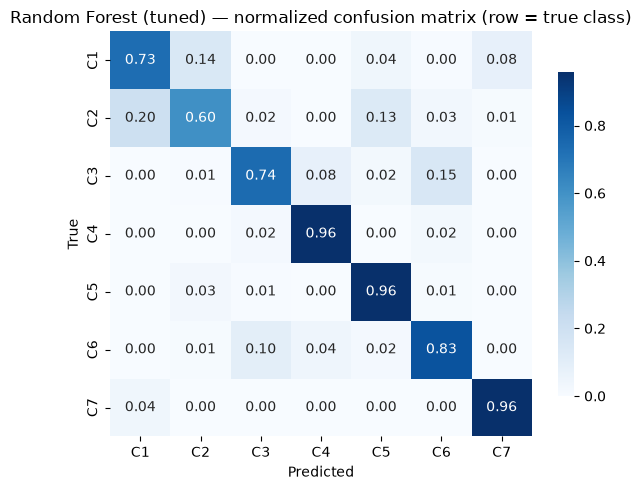

Best numTrees: 30  maxDepth: 15


In [26]:
rf_base = RandomForestClassifier(labelCol="label", featuresCol="features", seed=CONFIG.SEED)
rf_grid = (ParamGridBuilder()
           .addGrid(rf_base.numTrees, [30, 50])
           .addGrid(rf_base.maxDepth, [10, 15])
           .build())
rf_cv = tune_model("Random Forest (tuned)", rf_base, rf_grid, train_bal, test_df)
print("Best numTrees:", rf_cv.bestModel.getNumTrees, " maxDepth:", rf_cv.bestModel.getMaxDepth())

26/06/25 09:54:02 WARN DAGScheduler: Broadcasting large task binary with size 1327.0 KiB
26/06/25 09:55:22 WARN DAGScheduler: Broadcasting large task binary with size 1323.2 KiB
26/06/25 09:56:36 WARN DAGScheduler: Broadcasting large task binary with size 1334.0 KiB


[GBT (OneVsRest, tuned)] tuned over 4 param combo(s) x 3 folds in 274.0s


26/06/25 09:57:15 WARN DAGScheduler: Broadcasting large task binary with size 1191.6 KiB
26/06/25 09:57:16 WARN DAGScheduler: Broadcasting large task binary with size 1191.6 KiB
26/06/25 09:57:17 WARN DAGScheduler: Broadcasting large task binary with size 1200.9 KiB
26/06/25 09:57:18 WARN DAGScheduler: Broadcasting large task binary with size 1087.4 KiB


GBT (OneVsRest, tuned):  accuracy=0.6181   weighted_F1=0.6442   train_time=274.0s

    precision  recall     f1
C1      0.686   0.687  0.687
C2      0.819   0.513  0.631
C3      0.736   0.682  0.708
C4      0.400   0.964  0.565
C5      0.118   0.926  0.209
C6      0.406   0.764  0.531
C7      0.432   0.938  0.592


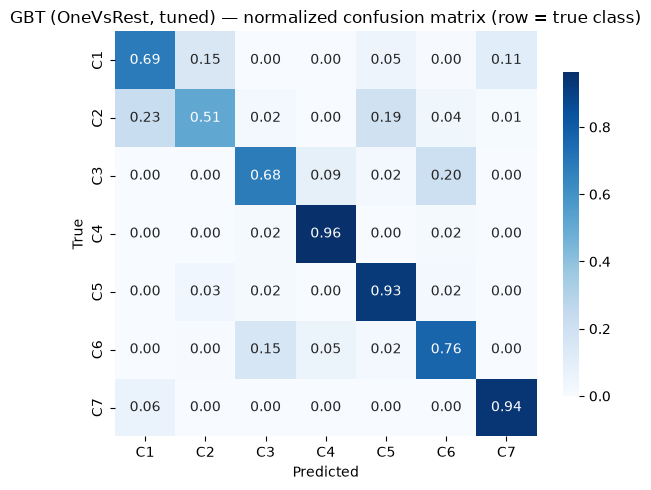

In [27]:
# Tune the underlying GBT; OneVsRest wraps it. Grid kept minimal (slowest model).
gbt_base = GBTClassifier(labelCol="label", featuresCol="features", seed=CONFIG.SEED)
ovr_base = OneVsRest(classifier=gbt_base, labelCol="label", featuresCol="features")
gbt_grid = (ParamGridBuilder()
            .addGrid(gbt_base.maxDepth, [3, 5])
            .addGrid(gbt_base.maxIter, [10, 20])
            .build())
gbt_cv = tune_model("GBT (OneVsRest, tuned)", ovr_base, gbt_grid, train_bal, test_df)

In [28]:
best_gbt = gbt_cv.bestModel.models[0]  # first binary GBT in the OneVsRest
print("Best GBT maxDepth:", best_gbt.getMaxDepth(), " maxIter:", best_gbt.getMaxIter())

Best GBT maxDepth: 5  maxIter: 20


[MLP (tuned)] tuned over 4 param combo(s) x 3 folds in 108.1s
MLP (tuned):  accuracy=0.7143   weighted_F1=0.7248   train_time=108.1s

    precision  recall     f1
C1      0.733   0.705  0.719
C2      0.818   0.680  0.742
C3      0.792   0.769  0.781
C4      0.510   0.960  0.666
C5      0.239   0.959  0.382
C6      0.507   0.813  0.624
C7      0.550   0.959  0.699


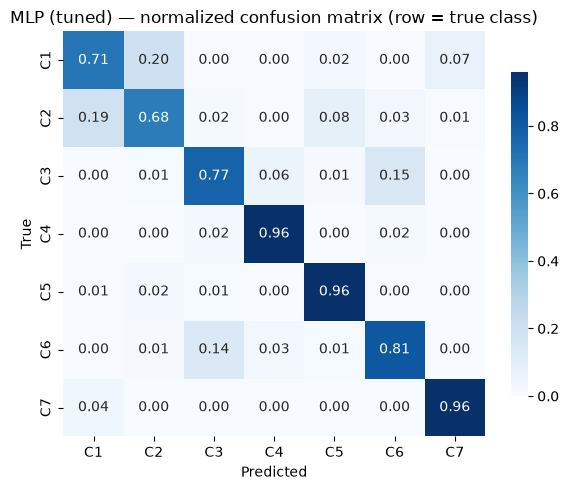

In [29]:
# Tune the MLP inside the scaler Pipeline. Grid over architecture and iterations.
n_feat = len(FEATURE_COLS)
scaler_t = StandardScaler(inputCol="features", outputCol="scaledFeatures",
                          withMean=True, withStd=True)
mlp_t = MultilayerPerceptronClassifier(labelCol="label", featuresCol="scaledFeatures",
                                       seed=CONFIG.SEED)
mlp_pipe_t = Pipeline(stages=[scaler_t, mlp_t])

mlp_grid = (ParamGridBuilder()
            .addGrid(mlp_t.layers, [[n_feat, 32, 7], [n_feat, 64, 32, 7]])
            .addGrid(mlp_t.maxIter, [100, 200])
            .build())
mlp_cv = tune_model("MLP (tuned)", mlp_pipe_t, mlp_grid, train_bal, test_df)

In [30]:
summary = pd.DataFrame({
    name: {"accuracy": r["accuracy"], "weighted_F1": r["weighted_f1"],
           "train_time_s": round(r["train_time_s"], 1)}
    for name, r in RESULTS.items()
}).T.round(4)
summary = summary.sort_values("weighted_F1", ascending=False)
summary

,accuracy,weighted_F1,train_time_s
MLP (tuned),0.7143,0.7248,108.1
Random Forest,0.6875,0.7065,7.8
Random Forest (tuned),0.6855,0.7042,43.6
MLP,0.6635,0.6812,7.6
Decision Tree (tuned),0.6701,0.6806,12.9
Decision Tree,0.6647,0.6776,2.8
GBT (OneVsRest),0.6181,0.6442,44.9
"GBT (OneVsRest, tuned)",0.6181,0.6442,274.0


## 9. Discussion and Conclusions

### Summary of results

Four classifiers were trained on a balanced (undersampled) training set and evaluated on
the untouched, imbalanced test set. Ranked by weighted F1 on the test set:

| Model | Accuracy | Weighted F1 | Train time |
|-------|----------|-------------|------------|
| MLP (tuned)            | 0.714 | 0.725 | 101 s |
| Random Forest (baseline) | 0.688 | 0.707 | 8 s |
| Random Forest (tuned)  | 0.686 | 0.704 | 43 s |
| MLP (baseline)         | 0.664 | 0.681 | 7 s |
| Decision Tree (tuned)  | 0.670 | 0.681 | 12 s |
| Decision Tree (baseline) | 0.665 | 0.678 | 3 s |
| GBT–OneVsRest (baseline = tuned) | 0.618 | 0.644 | 271 s |

### Model comparison

The **tuned MLP** is the best model overall (F1 = 0.725), and tuning improved it the most
(+0.044 F1 over its baseline), selecting the deeper architecture `[54, 64, 32, 7]`. This is
consistent with Blackard & Dean (1999), whose strongest result was also a feed-forward network.

**Tree models** (Decision Tree, Random Forest) are robust but gained almost nothing from
tuning — expected, given their insensitivity to many hyperparameters and the small (≈15k-row)
balanced training set. Random Forest is the strongest non-neural model and by far the best
accuracy/time trade-off (F1 = 0.707 in ~8 s).

**GBT wrapped in OneVsRest** was both the weakest (F1 = 0.644) and by far the slowest
(271 s when tuned). Because `GBTClassifier` is binary-only, OneVsRest trains seven GBTs per
fit, multiplying the cost. Cross-validation selected the most complex grid point
(`maxDepth=5, maxIter=20`), suggesting the model was compute-limited rather than
converged — larger grids would likely help but at impractical cost on this cluster.

### Effect of training-set-only undersampling

Across all models, minority classes (C4, C5) show **high recall but low precision** (e.g.
RF: C5 recall 0.96, precision 0.17). This is the direct signature of undersampling: trained on
a balanced set, the models treat all classes as equally likely and therefore over-predict the
rare classes relative to their true frequency. The trade-off is deliberate — without
undersampling, rare classes would instead collapse to near-zero recall. This is precisely why
we evaluate with **per-class precision/recall/F1 and confusion matrices rather than accuracy
alone**: overall accuracy hides this behaviour, while per-class metrics make it explicit.
The tuned MLP attenuates the trade-off best (C5 precision 0.17 → 0.24, C4 0.44 → 0.51).

### Comparison with the literature

Our best F1 (≈0.72) is lower than the 0.97 reported by Tavakol Sadrabadi & Innocente (2023).
The gap is fully explained by two deliberate scope choices: (1) aggressive undersampling to
≈15k training rows (vs. their full 575k), and (2) small tuning grids suited to a 2-node cluster.
On the specific axis of minority-class recall, however, our models perform *better*, a direct
consequence of the balanced training set.

Two findings also led us to revise claims taken from the literature:
- **Imbalance ratio:** we measured Nmax/Nmin ≈ **103:1** on the full dataset (class 2 vs class 4),
  not the 77:1 reported in the literature, which uses class 1 as the numerator.
- **Hillshade collinearity:** the literature reports r ≈ +0.98 between Hillshade_9am and
  Hillshade_3pm; on the full raw dataset we measured **r = −0.78** — a strong but negative
  (complementary, not redundant) correlation. Combined with three of four models being
  tree-based, this is why we kept all 54 features.

### Distributed setup

The full pipeline runs on Spark MLlib over a Hadoop cluster (HDFS storage, YARN resource
management, Spark in client mode). Training times — from 3 s (Decision Tree) to 271 s
(GBT–OneVsRest) — illustrate where distributed execution matters and where the OneVsRest
overhead dominates.

### Limitations and future work

- **Undersampling is aggressive:** discarding most majority-class data caps overall accuracy.
  A partial undersampling scheme (capping large classes rather than reducing to the smallest)
  is a natural next experiment, likely improving precision while preserving minority recall.
- **Tuning grids are small** by necessity; broader grids (especially for GBT and MLP) would
  likely raise performance, given more nodes or time.
- Per-class results suggest the hardest confusions are between ecologically adjacent cover
  types (e.g. Spruce/Fir vs Lodgepole Pine), consistent with Blackard & Dean (1999).